In [1]:
import json
from itertools import product
from pathlib import Path

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
plt.style.use("../clane.v2.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad
plt.rcParams["figure.dpi"] = 300

In [3]:
# load metadata on hcpya dataset from eval repo
hcpya_root = Path("/data/connor/fmri-fm-eval/datasets/HCP-YA/")

# map of "batch-id" -> list of subs
with (hcpya_root / "metadata/hcpya_subject_batch_splits.json").open() as f:
    hcpya_sub_splits = json.load(f)
print(len(hcpya_sub_splits))

hcpya_df = pd.read_parquet(hcpya_root / "metadata/hcpya_metadata.parquet")
hcpya_df = hcpya_df.loc[:, ["sub", "task", "mag", "dir", "tr", "n_frames"]]
print(hcpya_df.shape)
hcpya_df.head()

20
(21633, 6)


,sub,task,mag,dir,tr,n_frames
0,100206,REST1,3T,LR,0.72,1200
1,100206,REST1,3T,RL,0.72,1200
2,100206,REST2,3T,LR,0.72,1200
3,100206,REST2,3T,RL,0.72,1200
4,100206,EMOTION,3T,LR,0.72,176


In [4]:
# compute the number of patches per frame
# (though we don't end up using patches as the size metric)

# from einops import rearrange
# import flat_mae.nisc as nisc

# resampler = nisc.flat_resampler_fslr64k_224_560()
# mask = resampler.mask_
# print(mask.shape)

# patch_size = 16
# patch_mask = rearrange(mask, "(h p) (w q) -> h w (p q)", p=patch_size, q=patch_size).any(axis=-1)
# print(patch_mask.shape, patch_mask.sum())

# 364 nonempty patches
patches_per_frame = 364

In [5]:
# compute the size of each training data split
# splits are constructed by slicing shards
# there are 20 subject batches. one batch = 100 shards
# here we list the subject batch ranges
batch_ranges = {
    (100, 1): (0, 1),
    (200, 1): (0, 2),
    (400, 1): (0, 4),
    (800, 1): (0, 8),
    (1600, 1): (0, 16),
    (100, 2): (8, 9),
    (200, 2): (8, 10),
    (400, 2): (8, 12),
    (800, 2): (8, 16),
    (1600, 2): (0, 16),
}

target_tr = 1.0  # all timeseries resampled to tr 1.0
t_patch_size = 4  # for these runs
num_frames = 16

records = []
for (n, t), (start, stop) in batch_ranges.items():
    key = f"n{n}_{t}"
    split_sub_list = [
        sub for batch_id in range(start, stop) for sub in hcpya_sub_splits[f"batch-{batch_id:02d}"]
    ]
    split_df = hcpya_df.loc[hcpya_df["sub"].isin(split_sub_list)]
    duration = (split_df["n_frames"] * split_df["tr"]).sum()
    total_frames = int(duration / target_tr)
    total_samples = total_frames / num_frames
    total_patches = num_frames * patches_per_frame // t_patch_size
    record = {
        "run": key,
        "num_shards": n,
        "trial": t,
        "num_subs": len(split_sub_list),
        "duration": duration,
        "hours": duration / 3600,
        "frames": total_frames,
        "samples": total_samples,
        "patches": total_patches,
    }
    records.append(record)

split_counts = pd.DataFrame.from_records(records)
split_counts = split_counts.set_index("run")
split_counts = split_counts.sort_values(["num_shards", "trial"])
print(split_counts)

         num_shards  trial  num_subs      duration        hours   frames  \
run                                                                        
n100_1          100      1        59  4.692180e+05   130.338337   469218   
n100_2          100      2        48  3.487165e+05    96.865703   348716   
n200_1          200      1       117  9.064279e+05   251.785519   906427   
n200_2          200      2       108  8.572481e+05   238.124463   857248   
n400_1          400      1       227  1.637930e+06   454.980548  1637929   
n400_2          400      2       220  1.755124e+06   487.534326  1755123   
n800_1          800      1       448  3.192933e+06   886.925830  3192932   
n800_2          800      2       432  3.408482e+06   946.800440  3408481   
n1600_1        1600      1       880  6.601415e+06  1833.726270  6601414   
n1600_2        1600      2       880  6.601415e+06  1833.726270  6601414   

             samples  patches  
run                            
n100_1    29326.1250   

In [6]:
print(
    split_counts.loc[:, ["num_shards", "trial", "num_subs", "hours", "frames"]].to_latex(
        float_format="%.0f", index=False
    )
)

\begin{tabular}{rrrrr}
\toprule
num_shards & trial & num_subs & hours & frames \\
\midrule
100 & 1 & 59 & 130 & 469218 \\
100 & 2 & 48 & 97 & 348716 \\
200 & 1 & 117 & 252 & 906427 \\
200 & 2 & 108 & 238 & 857248 \\
400 & 1 & 227 & 455 & 1637929 \\
400 & 2 & 220 & 488 & 1755123 \\
800 & 1 & 448 & 887 & 3192932 \\
800 & 2 & 432 & 947 & 3408481 \\
1600 & 1 & 880 & 1834 & 6601414 \\
1600 & 2 & 880 & 1834 & 6601414 \\
\bottomrule
\end{tabular}



In [7]:
# load the full training logs for each run
tables = []
for n, t in batch_ranges:
    key = f"n{n}_{t}"
    log_path = Path(f"output/data_scaling/{key}/pretrain/log.json")
    table = pd.read_json(log_path, lines=True)
    assert len(table) == 100, f"incomplete run {key}"
    table.insert(0, "trial", t)
    table.insert(0, "num_shards", n)
    table.insert(0, "run", key)
    tables.append(table)

train_logs = pd.concat(tables, ignore_index=True)
print(train_logs.shape)
train_logs.head()

(1000, 10)


,run,num_shards,trial,epoch,train/lr,train/grad,train/loss,eval/hcp-train-subset/loss,eval/hcp-val/loss,eval/nsd-val/loss
0,n100_1,100,1,0,0.000013,0.057979,0.992739,0.990202,0.990444,0.990427
1,n100_1,100,1,1,0.000038,0.106730,0.984727,0.986966,0.988416,0.990074
2,n100_1,100,1,2,0.000063,0.149518,0.981253,0.981263,0.981571,0.986203
3,n100_1,100,1,3,0.000088,0.217402,0.972572,0.974039,0.975086,0.982094
4,n100_1,100,1,4,0.000113,0.216732,0.944941,0.928231,0.927232,0.903293


In [8]:
# get the best epoch and loss for both hcp and nsd
# note we find the best epoch for each dataset separately, since they need not be the same
records = []
for (run, n, t), group in train_logs.groupby(["run", "num_shards", "trial"]):
    hcp_idx = group["eval/hcp-val/loss"].argmin()
    hcp_loss = group.iloc[hcp_idx]["eval/hcp-val/loss"]
    nsd_idx = group["eval/nsd-val/loss"].argmin()
    nsd_loss = group.iloc[nsd_idx]["eval/nsd-val/loss"]
    record = {
        "run": run,
        "num_shards": n,
        "trial": t,
        "hcp_epoch": hcp_idx,
        "nsd_epoch": nsd_idx,
        "hcp_loss": hcp_loss,
        "nsd_loss": nsd_loss,
    }
    records.append(record)
best_losses = pd.DataFrame.from_records(records)
best_losses = best_losses.set_index("run")
best_losses = best_losses.sort_values(["num_shards", "trial"])
best_losses

,num_shards,trial,hcp_epoch,nsd_epoch,hcp_loss,nsd_loss
run,,,,,,
n100_1,100,1,10,8,0.859860,0.830546
n100_2,100,2,11,7,0.866139,0.840000
n200_1,200,1,13,13,0.851633,0.823157
n200_2,200,2,16,12,0.853310,0.821156
n400_1,400,1,26,23,0.845646,0.815022
n400_2,400,2,29,13,0.845635,0.817387
n800_1,800,1,98,38,0.837538,0.811880
n800_2,800,2,99,36,0.839451,0.813281
n1600_1,1600,1,95,45,0.828328,0.807802


In [9]:
def fit_power_law(x, y):
    """
    y = (x / a)^b
    log y = b log(x / a)
    log y = b log x - b log a
    log y = b log x + c

    c = - b log a
    a = exp(- c / b)
    """
    logx = np.log(x)
    logy = np.log(y)

    # fit line: logy = intercept + slope * logx
    slope, intercept = np.polyfit(logx, logy, 1)

    b = slope
    a = np.exp(-intercept / b)
    return a, b


def predict_power_law(x, a, b):
    return (np.array(x) / a) ** b

In [10]:
# fit power scaling laws for each dataset
power_laws = {}

x = split_counts["frames"]

# we fit power law on the three small runs and check the fit for bigger
mask = best_losses["num_shards"] < 800

for ds in ["hcp", "nsd"]:
    y = best_losses[f"{ds}_loss"]
    a, b = fit_power_law(x[mask], y[mask])
    y_pred = predict_power_law(x, a, b)
    print(f"{ds}: L = (N / {a:.0f})^{b:.3f}")
    power_laws[ds] = (a, b, y_pred)

hcp: L = (N / 15)^-0.014
nsd: L = (N / 7)^-0.017


In [11]:
# prop_cycle = plt.rcParams["axes.prop_cycle"]
# colors = prop_cycle.by_key()["color"]
colors = ["#0072B2", "#009E73", "#E69F00", "#D55E00", "#CC79A7", "#474747"]
print(colors)

['#0072B2', '#009E73', '#E69F00', '#D55E00', '#CC79A7', '#474747']


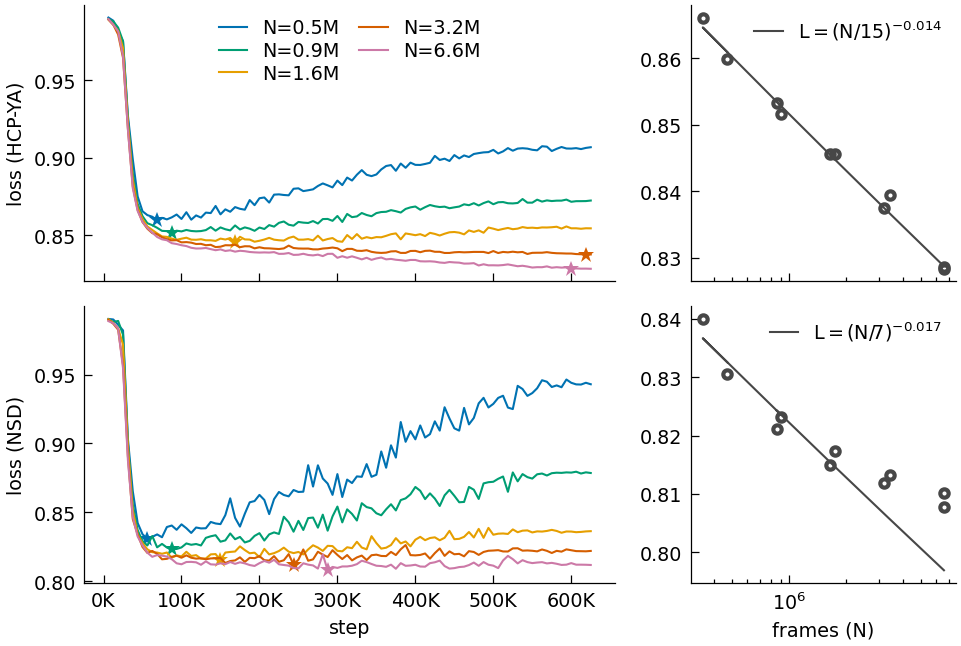

In [12]:
# 2 x 2 plot
# left col: test loss curves (aspect 2)
# right col: power law plots
f = plt.figure(figsize=(PLOTW, 2.2), constrained_layout=True)
gs = f.add_gridspec(2, 3)

ax1 = f.add_subplot(gs[0, :2])
ax2 = f.add_subplot(gs[1, :2], sharex=ax1)
ax3 = f.add_subplot(gs[0, 2])
ax4 = f.add_subplot(gs[1, 2], sharex=ax3)

# first trial only for loss curves
sub_logs = train_logs.query("trial == 1")

# steps
x = np.arange(1, 101) * 6250

line_color = colors[-1]

# loss curve for each dataset size
# best epoch indicated with star
for ii, (n, group) in enumerate(sub_logs.groupby("num_shards")):
    key = f"n{n}_1"
    num_frames = split_counts.loc[key, "frames"]
    best_row = best_losses.loc[key]
    # plot hcp
    ax1.plot(
        x,
        group["eval/hcp-val/loss"].values,
        lw=0.5,
        color=colors[ii],
        label=f"N={num_frames / 1e6:.1f}M",
    )
    ax1.plot(
        [x[int(best_row["hcp_epoch"])]],
        [best_row["hcp_loss"]],
        "*",
        color=colors[ii],
        ms=4,
        mec="none",
    )
    # plot nsd
    ax2.plot(x, group["eval/nsd-val/loss"].values, lw=0.5, color=colors[ii])
    ax2.plot(
        [x[int(best_row["nsd_epoch"])]],
        [best_row["nsd_loss"]],
        "*",
        color=colors[ii],
        ms=4,
        mec="none",
    )

ax1.tick_params("x", labelbottom=False)
ax3.tick_params("x", labelbottom=False)
ax2.xaxis.set_major_formatter(lambda x, pos: f"{x / 1000:.0f}K")
ax1.set_ylabel("loss (HCP-YA)", fontsize="small")
ax2.set_ylabel("loss (NSD)", fontsize="small")
ax2.set_xlabel("step", fontsize="small")
ax1.legend(loc="upper center", ncol=2, fontsize="small")

# power law curves
# note power laws are fit on < 800 shard datasets to check extrapolation
ax3.set_xscale("log")

x = split_counts["frames"]

y = best_losses["hcp_loss"]
a, b, y_pred = power_laws["hcp"]
ax3.plot(x, y, "o", mfc="none", ms=2, color=line_color)
ax3.plot(
    x,
    y_pred,
    "-",
    color=line_color,
    lw=0.5,
    label=f"$\mathregular{{L = (N / {a:.0f})^{{{b:.3f}}}}}$",
)
ax3.legend(loc="upper right", fontsize="small")

y = best_losses["nsd_loss"]
a, b, y_pred = power_laws["nsd"]
ax4.plot(x, y, "o", mfc="none", ms=2, color=line_color)
ax4.plot(
    x,
    y_pred,
    "-",
    color=line_color,
    lw=0.5,
    label=f"$\mathregular{{L = (N / {a:.0f})^{{{b:.3f}}}}}$",
)
ax4.legend(loc="upper right", fontsize="small")
ax4.set_xlabel("frames (N)", fontsize="small")

f.savefig("results/data_scaling.pdf")

In [13]:
# downstream analysis
num_shards = [100, 200, 400, 800, 1600]

tables = []
for n, t in product(num_shards, [1, 2]):
    key = f"n{n}_{t}"
    paths = sorted(Path(f"output/data_scaling/{key}/eval_v2").rglob("eval_table.csv"))
    table = pd.concat((pd.read_csv(p) for p in paths), ignore_index=True)
    table.insert(0, "repeat", t)
    table.insert(0, "num_shards", n)
    table.insert(0, "run", key)
    tables.append(table)
table = pd.concat(tables, ignore_index=True)
print(table.shape)
table.head()

(28350, 23)


,run,num_shards,repeat,model,repr,clf,dataset,trial,C,split,...,f1_std,bacc,bacc_std,ckpt,epoch,lr,wd,hparam_id,hparam,loss
0,n100_1,100,1,flat_mae,cls,logistic,aabc_age,NaN,0.005995,train,...,0.020363,0.648638,0.019995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,n100_1,100,1,flat_mae,cls,logistic,aabc_age,NaN,0.005995,test,...,0.067505,0.394918,0.065601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,n100_1,100,1,flat_mae,cls,logistic,aabc_age,1.0,0.046416,train,...,0.014826,0.866347,0.014698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,n100_1,100,1,flat_mae,cls,logistic,aabc_age,1.0,0.046416,test,...,0.060490,0.342491,0.061300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,n100_1,100,1,flat_mae,cls,logistic,aabc_age,2.0,0.046416,train,...,0.014870,0.857797,0.014810,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
state_datasets = ["hcpya_task21", "nsd_cococlip"]

state_summary = (
    table.loc[(table["split"] == "test") & (table["dataset"].isin(state_datasets))]
    .dropna(axis=1, how="all")
    .pivot_table(
        values=["acc", "acc_std"], index=["num_shards", "repeat", "repr", "clf"], columns="dataset"
    )
    .loc[(slice(None), slice(None), "patch", "attn")]
)
state_summary

acc                   acc_std             
dataset           hcpya_task21 nsd_cococlip hcpya_task21 nsd_cococlip
num_shards repeat                                                    
100        1          0.975397     0.271800     0.002166     0.005389
           2          0.963294     0.259184     0.002536     0.005124
200        1          0.972619     0.281633     0.002196     0.005472
           2          0.976984     0.279592     0.002168     0.005301
400        1          0.980556     0.299443     0.001995     0.005293
           2          0.973214     0.276994     0.002277     0.005321
800        1          0.988095     0.307050     0.001479     0.005251
           2          0.983929     0.285529     0.001679     0.005355
1600       1          0.990079     0.316327     0.001384     0.005421
           2          0.985317     0.314471     0.001679     0.005444

In [15]:
def sem(x):
    return x.std() / (len(x) ** 0.5)


trait_datasets = ["aabc_age", "aabc_sex"]
trait_metric = "bacc"

trait_repr = "patch"

trait_summary = (
    table.loc[
        (table["split"] == "test") & (table["dataset"].isin(trait_datasets)) & (table["trial"] > 0)
    ]
    .dropna(axis=1, how="all")
    .pivot_table(
        values=[trait_metric],
        index=["num_shards", "repeat", "repr", "clf"],
        columns="dataset",
        aggfunc=["mean", sem],
    )
    .loc[(slice(None), slice(None), trait_repr, "logistic")]
)
trait_summary.columns = pd.MultiIndex.from_tuples(
    [(metric, ds) for metric, ds in product(["acc", "acc_std"], trait_datasets)]
)
trait_summary

acc             acc_std          
                   aabc_age  aabc_sex  aabc_age  aabc_sex
num_shards repeat                                        
100        1       0.477743  0.821746  0.006015  0.005046
           2       0.454059  0.834905  0.006546  0.004739
200        1       0.490309  0.832758  0.005830  0.004894
           2       0.472642  0.824918  0.007018  0.004917
400        1       0.472340  0.842052  0.006154  0.004815
           2       0.463798  0.842514  0.006197  0.005153
800        1       0.441783  0.865245  0.006014  0.004642
           2       0.458008  0.863471  0.007258  0.004719
1600       1       0.450483  0.876651  0.006400  0.004581
           2       0.472699  0.863628  0.006349  0.004606

In [16]:
summary = pd.concat([state_summary, trait_summary], axis=1)
summary

acc                   acc_std               \
                  hcpya_task21 nsd_cococlip hcpya_task21 nsd_cococlip   
num_shards repeat                                                       
100        1          0.975397     0.271800     0.002166     0.005389   
           2          0.963294     0.259184     0.002536     0.005124   
200        1          0.972619     0.281633     0.002196     0.005472   
           2          0.976984     0.279592     0.002168     0.005301   
400        1          0.980556     0.299443     0.001995     0.005293   
           2          0.973214     0.276994     0.002277     0.005321   
800        1          0.988095     0.307050     0.001479     0.005251   
           2          0.983929     0.285529     0.001679     0.005355   
1600       1          0.990079     0.316327     0.001384     0.005421   
           2          0.985317     0.314471     0.001679     0.005444   

                        acc             acc_std            
                   aabc_age  aabc_sex  aabc_age  aabc_sex  
num_shards repeat                                          
100        1       0.477743  0.821746  0.006015  0.005046  
           2       0.454059  0.834905  0.006546  0.004739  
200        1       0.490309  0.832758  0.005830  0.004894  
           2       0.472642  0.824918  0.007018  0.004917  
400        1       0.472340  0.842052  0.006154  0.004815  
           2       0.463798  0.842514  0.006197  0.005153  
800        1       0.441783  0.865245  0.006014  0.004642  
           2       0.458008  0.863471  0.007258  0.004719  
1600       1       0.450483  0.876651  0.006400  0.004581  
           2       0.472699  0.863628  0.006349  0.004606

In [17]:
DATASET_NAMES = {
    "abide_dx": "ABIDE Dx",
    "abide_age": "ABIDE Age",
    "abide_sex": "ABIDE Sex",
    "adhd200_dx": "ADHD200 Dx",
    "adhd200_sex": "ADHD200 Sex",
    "adni_ad_vs_cn": "ADNI Dx",
    "adni_sex": "ADNI Sex",
    "ppmi_dx": "PPMI Dx",
    "ppmi_sex": "PPMI Sex",
    "ppmi_age": "PPMI Age",
    "hcpya_rest1lr_gender": "HCP-YA Sex",
    "hcpya_rest1lr_age": "HCP-YA Age",
    "hcpya_rest1lr_neofacn": "HCP-YA NEO-N",
    "aabc_sex": "HCP-A Sex",
    "aabc_age": "HCP-A Age",
    "hcpya_task21": "HCP-YA Task21",
    "nsd_cococlip": "NSD COCO24",
}

In [18]:
# shards_to_frames = split_counts.groupby("num_shards").agg({"frames": "mean"})["frames"].to_dict()

# use size of first shard for consistency with earlier plot (bit of hack)
shards_to_frames = {
    row["num_shards"]: row["frames"] for _, row in split_counts.query("trial == 1").iterrows()
}

In [19]:
sigmas = {
    "abide_dx": 0.009,
    "adhd200_dx": 0.0042,
    "adni_ad_vs_cn": 0.013,
    "ppmi_dx": 0.0126,
    "aabc_age": 0.0115,
    "aabc_sex": 0.0099,
    "hcpya_task21": 0.0011,
    "nsd_cococlip": 0.0101,
}

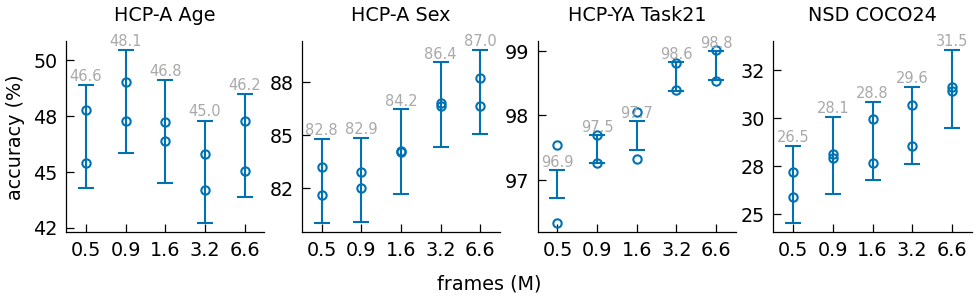

In [20]:
from matplotlib.ticker import FormatStrFormatter

# datasets = ["aabc_sex", "hcpya_rest1lr_gender", "hcpya_task21", "nsd_cococlip"]
datasets = ["aabc_age", "aabc_sex", "hcpya_task21", "nsd_cococlip"]

f, axs = plt.subplots(1, len(datasets), figsize=(PLOTW, 1.0))

ticklabels = [f"{frames / 1e6:.1f}" for frames in shards_to_frames.values()]
for ii, ds in enumerate(datasets):
    ax = axs[ii]
    plt.sca(ax)
    for jj, n in enumerate(num_shards):
        subdf = summary.loc[n]
        scores = 100 * subdf.loc[:, ("acc", ds)].values
        stds = 100 * subdf.loc[:, ("acc_std", ds)].values
        score = np.mean(scores)
        # std = np.sqrt(np.mean(stds**2))
        std = 100 * sigmas[ds]
        ax.errorbar(
            [jj],
            [score],
            yerr=[2 * std],
            color=colors[0],
            elinewidth=0.5,
            capsize=2.0,
            capthick=0.5,
        )
        ax.plot([jj, jj], scores, "o", color=colors[0], ms=2, mfc="none", mew=0.5)
        ax.text(
            jj,
            score + 1.03 * 2 * std,
            f"{score:.1f}",
            fontsize=3.5,
            color="darkgray",
            ha="center",
            va="bottom",
        )

    ax.set_title(DATASET_NAMES[ds], fontsize="small", pad=5)
    if ii == 0:
        ax.set_ylabel("accuracy (%)", fontsize="small")

    ax.set_xticks(np.arange(len(num_shards)), ticklabels)
    ax.set_xlim(-0.5, len(num_shards) - 0.5)
    # if ds == "nsd_cococlip":
    #     ax.set_yticks([26, 28, 30, 32])
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

plt.tight_layout(pad=0.2)

f.subplots_adjust(bottom=0.23)
f.text(0.5, 0.04, "frames (M)", ha="center", fontsize="small")
f.savefig("results/data_scaling_downstream.pdf")